        Date  Price  Price_diff12  lag_1  lag_12  month
0 1952-01-01   34.6         -0.12   0.00     0.0      1
1 1952-02-01   34.6         -0.12  -0.12     0.0      2
2 1952-03-01   34.6         -0.12  -0.12     0.0      3
3 1952-04-01   34.6         -0.12  -0.12     0.0      4
4 1952-05-01   34.6         -0.12  -0.12     0.0      5
RMSE: 83.02392761380143
MAE : 63.140755818181766
R^2 : 0.8141246981799795
保存しました: rf_forecast_result.csv


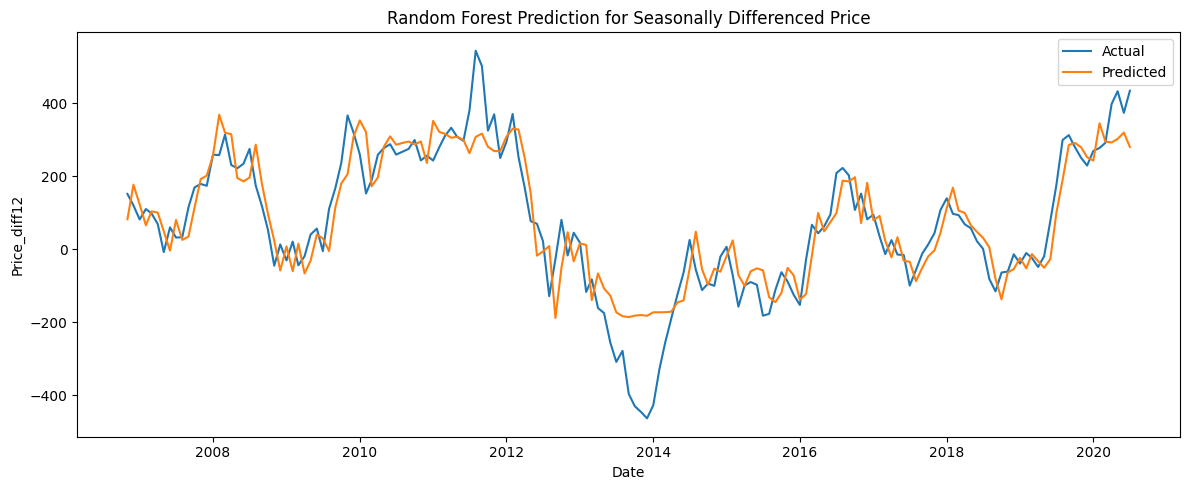


Feature Importances:
lag_1     0.885749
lag_2     0.038949
lag_12    0.026572
lag_3     0.018659
month     0.015586
lag_6     0.014486
dtype: float64


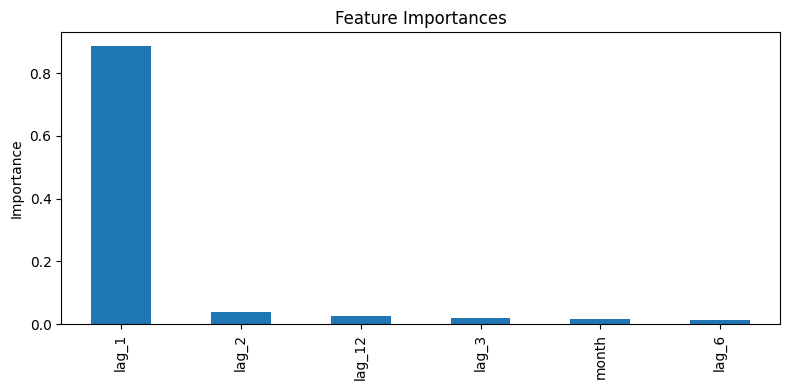

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# =========================================
# 1. CSV読み込み
# =========================================
df = pd.read_csv("monthly.csv")

# =========================================
# 2. 日付変換
# =========================================
df["Date"] = pd.to_datetime(df["Date"])

# =========================================
# 3. 必要列だけ確認
# =========================================
print("列名:", df.columns.tolist())
print(df.head())

# =========================================
# 4. 期間指定：1950-01 ～ 2020-07
# =========================================
start = pd.Timestamp("1950-01-01")
end   = pd.Timestamp("2020-07-01")

df_period = df[(df["Date"] >= start) & (df["Date"] <= end)].copy()
df_period = df_period.sort_values("Date").reset_index(drop=True)

print("期間抽出後の件数:", len(df_period))
print(df_period.head())
print(df_period.tail())

# =========================================
# 5. 抽出データ保存
# =========================================
df_period.to_csv("monthly_1950-01_2020-07.csv", index=False, encoding="utf-8-sig")
print("保存しました: monthly_1950-01_2020-07.csv")

# =========================================
# 6. 元系列プロット
# =========================================
plt.figure(figsize=(12, 4))
plt.plot(df_period["Date"], df_period["Price"])
plt.title("Price (1950-01 to 2020-07)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# =========================================
# 7. 季節差分（12か月差分）
# =========================================
differenced = df_period.copy()
differenced["Price"] = differenced["Price"].diff(12)

# NaN削除
differenced = differenced.dropna(subset=["Price"]).reset_index(drop=True)

print("季節差分後の件数:", len(differenced))
print(differenced.head())

# =========================================
# 8. 季節差分データ保存
# =========================================
differenced.to_csv("seasonally_adjusted.csv", index=False, encoding="utf-8-sig")
print("保存しました: seasonally_adjusted.csv")

# =========================================
# 9. 季節差分後プロット
# =========================================
plt.figure(figsize=(12, 4))
plt.plot(differenced["Date"], differenced["Price"])
plt.title("Seasonally Differenced Price (12 months)")
plt.xlabel("Date")
plt.ylabel("Differenced Price")
plt.tight_layout()
plt.show()

# =========================================
# 10. ACF（元系列）
# =========================================
plt.figure(figsize=(8, 4))
plot_acf(df_period["Price"].dropna(), lags=40)
plt.title("ACF of Original Price")
plt.tight_layout()
plt.show()

# =========================================
# 11. ACF（季節差分後）
# =========================================
plt.figure(figsize=(8, 4))
plot_acf(differenced["Price"].dropna(), lags=40)
plt.title("ACF of Seasonally Differenced Price")
plt.tight_layout()
plt.show()

# =========================================
# 12. PACF（季節差分後）
# =========================================
plt.figure(figsize=(8, 4))
plot_pacf(differenced["Price"].dropna(), lags=40, method="ywm")
plt.title("PACF of Seasonally Differenced Price")
plt.tight_layout()
plt.show()

# reframe as supervised learning
dataframe = pd.DataFrame()
for i in range(12,0,-1):
    dataframe['t-'+str(i)] = df.shift(i).values[:,0]
dataframe['t'] = df.values[:,0]
print(dataframe.head(13))
dataframe = dataframe[13:]
# save to new file
dataframe.to_csv('lags_12months_features.csv', index=False)


